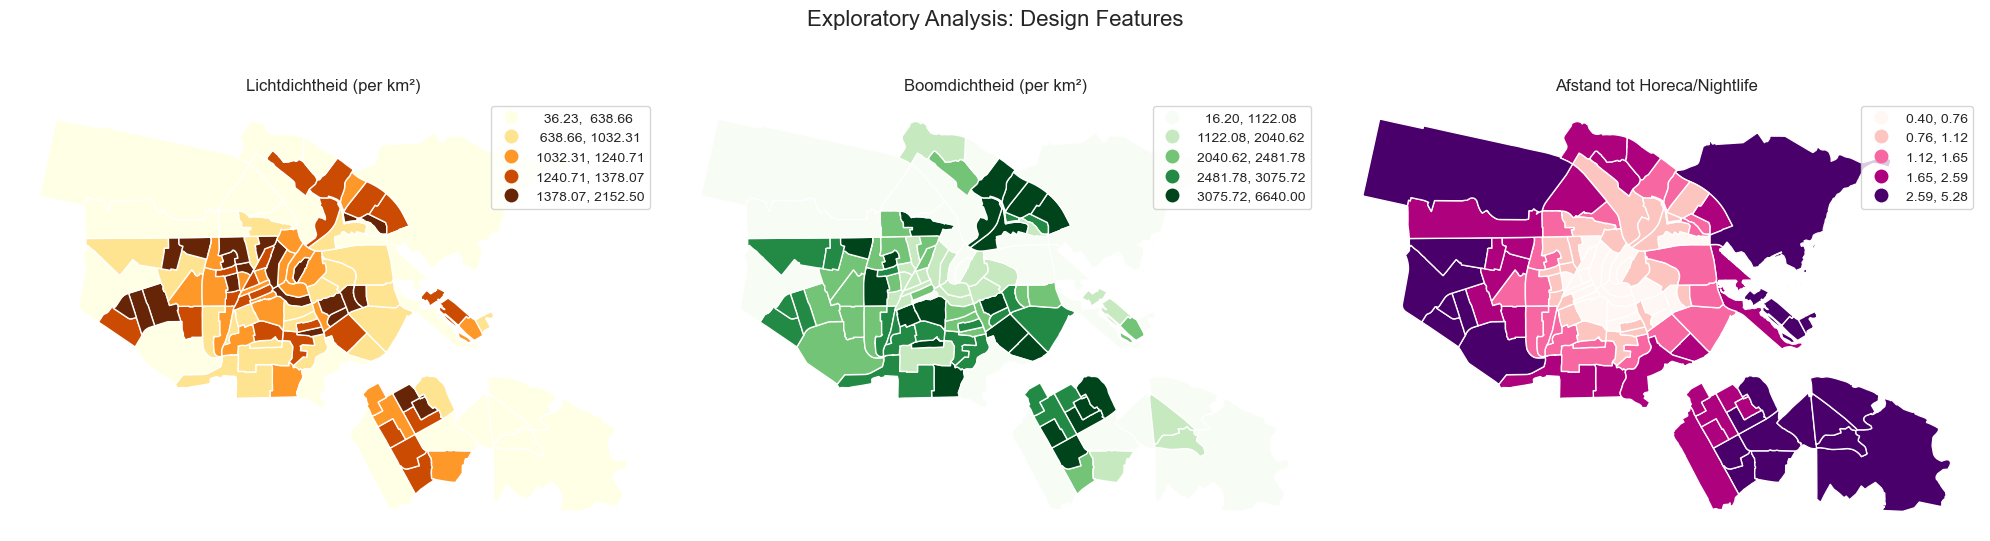

In [11]:
import matplotlib.pyplot as plt

# Zorg dat je gdf (GeoDataFrame) schoon is
# We kiezen 'mean_dist_nightlife' als relevante facility (Horeca trekt vaak misdaad aan)
cols = ['Lights_per_km2', 'Trees_per_km2', 'mean_dist_nightlife', 'Misdrijven_per_1000_inwoners']
gdf_clean = gdf.dropna(subset=cols).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Light Density
gdf_clean.plot(column='Lights_per_km2', cmap='YlOrBr', scheme='quantiles', k=5, legend=True, ax=axes[0])
axes[0].set_title('Lichtdichtheid (per km²)')
axes[0].axis('off')

# 2. Tree Density
gdf_clean.plot(column='Trees_per_km2', cmap='Greens', scheme='quantiles', k=5, legend=True, ax=axes[1])
axes[1].set_title('Boomdichtheid (per km²)')
axes[1].axis('off')

# 3. Facility: Afstand tot Nightlife
# (Kies 1 relevante facility zoals gevraagd)
gdf_clean.plot(column='mean_dist_nightlife', cmap='RdPu', scheme='quantiles', k=5, legend=True, ax=axes[2])
axes[2].set_title('Afstand tot Horeca/Nightlife')
axes[2].axis('off')

plt.suptitle("Exploratory Analysis: Design Features", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
from libpysal.weights import Queen
from esda.moran import Moran

# 1. Maak de buren-matrix (Spatial Weights Matrix)
w = Queen.from_dataframe(gdf_clean)
w.transform = 'r'  # Row-standardization (belangrijk!)

# 2. Bereken Global Moran's I voor Crime, Licht en Bomen
vars_to_test = {
    'Crime Rate': 'Misdrijven_per_1000_inwoners',
    'Light Density': 'Lights_per_km2',
    'Tree Density': 'Trees_per_km2'
}

print("--- Global Spatial Autocorrelation (Moran's I) ---")
for name, col in vars_to_test.items():
    moran = Moran(gdf_clean[col], w)
    print(f"\nVariabele: {name}")
    print(f"Moran's I: {moran.I:.3f}")
    print(f"P-value:   {moran.p_sim:.5f}")

    # Interpretatie printen ter hulp
    if moran.p_sim < 0.05:
        if moran.I > 0:
            print("-> Conclusie: Significant geclusterd (High near High)")
        else:
            print("-> Conclusie: Significant verspreid (Schaakbord patroon)")
    else:
        print("-> Conclusie: Willekeurig verdeeld (Geen ruimtelijk patroon)")

--- Global Spatial Autocorrelation (Moran's I) ---

Variabele: Crime Rate
Moran's I: 0.092
P-value:   0.00200
-> Conclusie: Significant geclusterd (High near High)

Variabele: Light Density
Moran's I: 0.287
P-value:   0.00100
-> Conclusie: Significant geclusterd (High near High)

Variabele: Tree Density
Moran's I: 0.185
P-value:   0.00400
-> Conclusie: Significant geclusterd (High near High)


/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_39784/3909496241.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_clean)
/Users/yoran/miniconda3/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


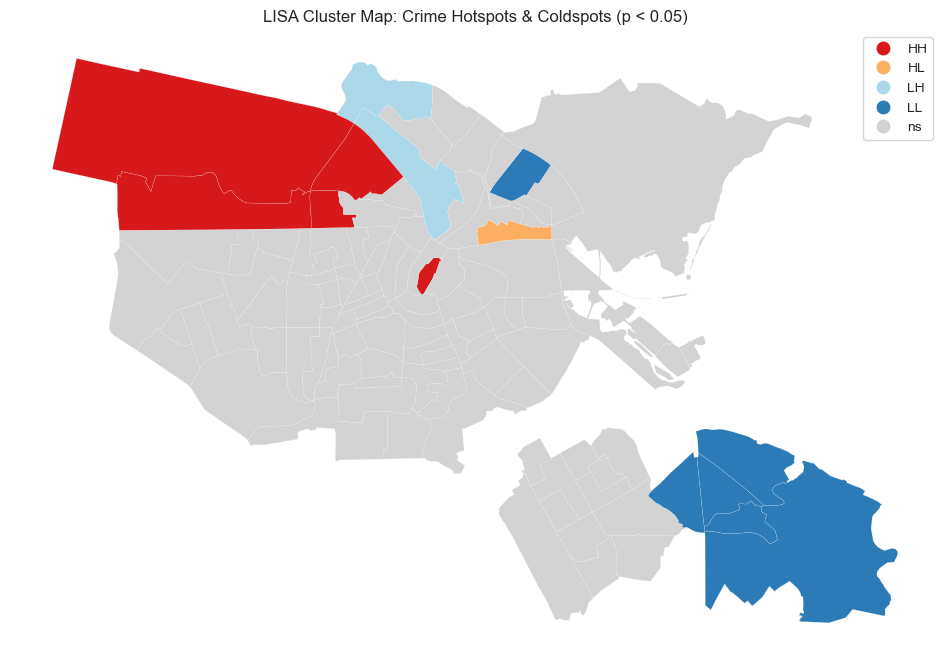

In [13]:
from esda.moran import Moran_Local
from splot.esda import lisa_cluster, plot_local_autocorrelation

# Bereken Local Moran's I voor Crime Rate
y = gdf_clean['Misdrijven_per_1000_inwoners']
lisa = Moran_Local(y, w)

# Plot de Cluster Map
fig, ax = plt.subplots(figsize=(12, 12))
lisa_cluster(lisa, gdf_clean, p=0.05, ax=ax)
ax.set_title("LISA Cluster Map: Crime Hotspots & Coldspots (p < 0.05)")
plt.show()

# Optioneel: Print de wijken die in de clusters vallen (voor je rapport)
# Rood (HH) = Probleemwijken
# Blauw (LL) = Veilige bubbels